Preprocessing for new data for transformer method


In [ ]:
# Import libraries

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import re

In [ ]:
# Cell 2 - Load data
csv_paths = list(Path("../Dataset/data_new_approach/").glob("*.csv"))
raw = pd.concat(
    [
        pd.read_csv(p, dtype=str).assign(source_file=p.name)
        for p in csv_paths
    ],
    ignore_index=True
)

print(f"Shape: {raw.shape}")
raw.head()
# Basic check
print(raw.info())
print("\nMissing values:")
print(raw.isnull().sum())

print("\nPlatform distribution:")
print(raw['platform'].value_counts())

print("\nRating distribution:")
print(raw['rating'].value_counts().sort_index())

Shape: (5450, 14)


,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file
0,app_store,us,1489511701.0,13976661175,2026-04-19T18:13:04-07:00,errttrwfdsbvxd,3,No ATM option,No debit card 😣,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv
1,app_store,us,1489511701.0,13968552342,2026-04-17T13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv
2,app_store,us,1489511701.0,13967597795,2026-04-17T07:34:37-07:00,Pichu4ever,5,Pato,Great,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv
3,app_store,us,1489511701.0,13965458699,2026-04-16T16:11:11-07:00,Ann22k,5,Saving or CD,Easy to navigate and transfers back to account...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv
4,app_store,us,1489511701.0,13963956841,2026-04-16T06:48:48-07:00,binbincheong,5,Easy peasy,Very easy to use and efficient! Good interest...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv


In [ ]:
# Select relevant columns & basic cleaning
df = raw[['platform', 'storefront', 'rating', 'title', 'review', 'date', 'source_file']].copy()

# Fix dtypes
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['title'] = df['title'].fillna('')
df['text'] = df.apply(
    lambda row: (row['title'] + ' ' + row['review']).strip() if row['title'] else row['review'],
    axis=1
)

print(df.shape)
print(df[['platform', 'title', 'review', 'text']].head(5))

(5450, 8)
    platform          title  \
0  app_store  No ATM option   
1  app_store    Great Bank.   
2  app_store           Pato   
3  app_store   Saving or CD   
4  app_store     Easy peasy   

                                              review  \
0                                    No debit card 😣   
1  Really easy bank to use. The best interest rat...   
2                                              Great   
3  Easy to navigate and transfers back to account...   
4  Very easy to use and efficient!  Good interest...   

                                                text  
0                      No ATM option No debit card 😣  
1  Great Bank. Really easy bank to use. The best ...  
2                                         Pato Great  
3  Saving or CD Easy to navigate and transfers ba...  
4  Easy peasy Very easy to use and efficient!  Go...  


In [ ]:
# Create sentiment label from rating
def rating_to_sentiment(r):
    if r <= 2:
        return 'negative'
    elif r == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['rating'].apply(rating_to_sentiment)
df['label'] = df['sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})

print(df['sentiment'].value_counts())
print(df['label'].value_counts())

sentiment
positive    3575
negative    1641
neutral      234
Name: count, dtype: int64
label
2    3575
0    1641
1     234
Name: count, dtype: int64


In [ ]:
# Text cleaning
# for bert model i remove URLs, punctuation, extra spaces and lowercases

def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text)
    text = text.lower()                      
    text = re.sub(r'http\S+|www\S+', '', text) 
    text = re.sub(r'[^\w\s]', ' ', text)        
    text = re.sub(r'\s+', ' ', text).strip()   
    return text

df['text_clean'] = df['text'].apply(clean_text)

print(df[['review', 'text_clean']].head(3))
df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)
print(f"\nFinal shape: {df.shape}")

                                              review  \
0                                    No debit card 😣   
1  Really easy bank to use. The best interest rat...   
2                                              Great   

                                          text_clean  
0                        no atm option no debit card  
1  great bank really easy bank to use the best in...  
2                                         pato great  

Final shape: (5427, 11)


count    5427.000000
mean       22.597936
std        29.867630
min         1.000000
25%         4.000000
50%        12.000000
75%        29.000000
max       387.000000
Name: text_length, dtype: float64

Reviews > 512 words: 0
Reviews > 256 words: 8
Reviews > 128 words: 66


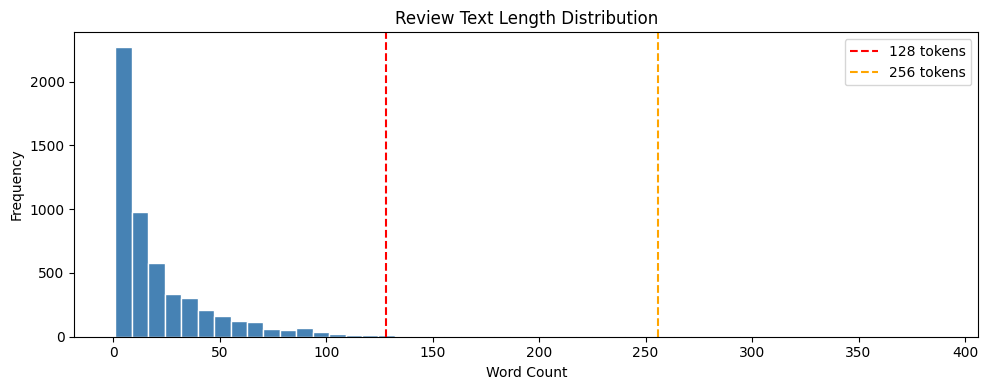

In [ ]:
# Check text length
df['text_length'] = df['text_clean'].apply(lambda x: len(x.split()))

print(df['text_length'].describe())
print(f"\nReviews > 512 words: {(df['text_length'] > 512).sum()}")
print(f"Reviews > 256 words: {(df['text_length'] > 256).sum()}")
print(f"Reviews > 128 words: {(df['text_length'] > 128).sum()}")

# Visualize
plt.figure(figsize=(10, 4))
plt.hist(df['text_length'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(128, color='red', linestyle='--', label='128 tokens')
plt.axvline(256, color='orange', linestyle='--', label='256 tokens')
plt.title('Review Text Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150)
plt.show()
# max length not over 512, available for bert model